In [10]:
import torch

torch.serialization.add_safe_globals([slice])

In [38]:
import logging
import os
import random
import time
import warnings
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from e3nn.nn import Gate
from e3nn.o3 import FullyConnectedTensorProduct, Irrep, Irreps, SphericalHarmonics
from mace.data import (
    AtomicData,
    Configuration,
    Configurations,
    KeySpecification,
    load_from_xyz,
)
from mace.modules import (
    EquivariantProductBasisBlock,
    LinearNodeEmbeddingBlock,
    RadialEmbeddingBlock,
)
from mace.modules.blocks import RealAgnosticResidualInteractionBlock
from mace.tools import AtomicNumberTable
from numpy.typing import NDArray
from scipy.spatial import cKDTree
from sklearn.model_selection import train_test_split
from torch import Tensor, nn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import scatter
from tqdm import tqdm

logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

## Data

In [13]:
def load_synthetic_data(
    data_root: Path, 
    structures: list[str],
) -> dict[str, dict[float, Configurations]]:
    result: dict[str, dict[float, Configurations]] = {}

    for crystal_type in structures:
        crystal_dir = data_root / crystal_type
        perturb_to_configs: dict[float, Configurations] = {}

        files = sorted(f for f in os.listdir(crystal_dir) if f.endswith(".gz"))

        for f in tqdm(files, desc=f"Loading {crystal_type}"):
            _, configs = load_from_xyz(
                str(crystal_dir / f),
                key_specification=KeySpecification.from_defaults(),
                no_data_ok=True
            )
            perturb_to_configs[float(f[:-3])] = configs

        result[crystal_type] = perturb_to_configs

    return result


def load_real_data(
    data_root: Path,
    structures: list[str],
) -> dict[str, dict[float, Configurations]]:
    result: dict[str, dict[float, Configurations]] = {}

    for struct_name in structures:
        exp_dir = data_root / struct_name
        temp_to_configs: dict[float, Configurations] = {}

        files = [
            fname for fname in sorted(os.listdir(exp_dir)) 
            if "relaxed" not in fname and fname.endswith(".gz")
        ]

        for fname in tqdm(files, desc=f"Loading {struct_name}"):
            _, configs = load_from_xyz(
                str(exp_dir / fname),
                key_specification=KeySpecification.from_defaults(),
                no_data_ok=True
            )
            temp_to_configs[float(fname[5:-3])] = configs

        result[struct_name] = temp_to_configs

    return result

In [14]:
def mean_knn_distance(
    configs: Configuration | Configurations,
    num_neighbors: int = 24,
) -> float:
    if isinstance(configs, Configuration):
        configs = [configs]

    total_dist = 0.0
    total_atoms = 0

    for config in configs:
        positions, cell, pbc = config.positions, config.cell, config.pbc

        if cell is not None and pbc is not None and np.any(pbc):
            boxsize = np.diag(np.asarray(cell, dtype=np.float64))
            positions = positions % boxsize
            tree = cKDTree(positions, boxsize=boxsize)
        else:
            print("No PBC is applied!")
            tree = cKDTree(positions)

        distances, _ = tree.query(positions, k=num_neighbors + 1)
        nn_distances = distances[:, 1:]

        total_dist += nn_distances.sum()
        total_atoms += len(positions)

    return float(total_dist / (total_atoms * num_neighbors))

In [15]:
SYNTH_STRUCTURES = ["bcc", "fcc", "hcp", "cd"]
REAL_STRUCTURES = ["li_bcc", "al_fcc", "ti_hcp", "ge_cd"]
REAL_TO_SYNTH = {
    "li_bcc": "bcc",
    "al_fcc": "fcc",
    "ti_hcp": "hcp",
    "ge_cd": "cd",
}
T_ML = {"li_bcc": 1.20, "al_fcc": 1.16, "ti_hcp": 1.16, "ge_cd": 1.32}

In [16]:
synth_data = load_synthetic_data(Path("synthetic_data"),  SYNTH_STRUCTURES)

Loading cd: 100%|██████████| 10/10 [00:00<00:00, 67.44it/s]


In [17]:
real_data = load_real_data(Path("data"), REAL_STRUCTURES)

Loading ge_cd: 100%|██████████| 40/40 [00:11<00:00,  3.48it/s]


In [19]:
synth_mean_dist = {
    structure: {}
    for structure in SYNTH_STRUCTURES
}

for structure, info in synth_data.items():
    for t, cfgs in tqdm(info.items(), desc=f"Calculating {structure}"):
        synth_mean_dist[structure][t] = mean_knn_distance(cfgs)

Calculating cd: 100%|██████████| 10/10 [00:00<00:00, 57.24it/s]


In [20]:
real_mean_dist: dict[str, dict[float, float]] = {
    structure: {}
    for structure in REAL_STRUCTURES
}

for structure, info in real_data.items():
    for t, cfgs in tqdm(info.items(), desc=f"Calculating {structure}"):
        real_mean_dist[structure][t] = mean_knn_distance(cfgs)

Calculating ge_cd: 100%|██████████| 40/40 [00:30<00:00,  1.29it/s]


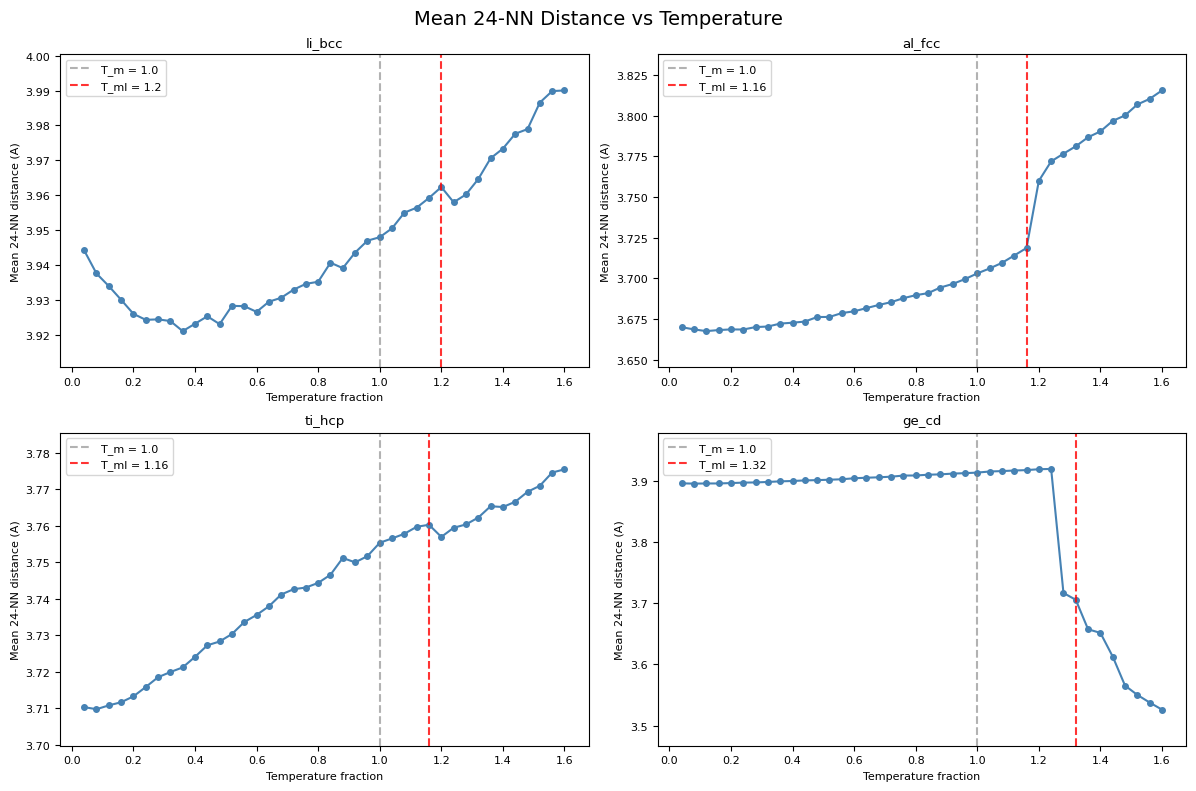

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, name in zip(axes.flatten(), REAL_STRUCTURES, strict=True):
    temps = sorted(real_mean_dist[name])
    dists = [real_mean_dist[name][t] for t in temps]
    
    ax.plot(temps, dists, "o-", markersize=4, color="steelblue")
    ax.axvline(1.0, color="gray", linestyle="--", alpha=0.6, label="T_m = 1.0")
    ax.axvline(
        T_ML[name], color="red", linestyle="--", alpha=0.8,
        label=f"T_ml = {T_ML[name]}"
    )

    ax.set_title(name)
    ax.set_xlabel("Temperature fraction")
    ax.set_ylabel("Mean 24-NN distance (A)")
    ax.legend(fontsize=8)

    ymin, ymax = min(dists), max(dists)
    margin = max((ymax - ymin) * 0.15, 0.01)
    ax.set_ylim(ymin - margin, ymax + margin)

fig.suptitle("Mean 24-NN Distance vs Temperature", fontsize=14)
plt.tight_layout()
plt.show()

One possible metric for scale is to take the average $24$-NN distance at $T=T_m$ and then divide this by the average of all synthetic data relating to the structure. My reasoning behind this was that higher temperature things are harder so we want them to be as in-distribution as possible. This made its performance better than the idea below but I think it is too "overfitted".

In [25]:
synth_global_average: dict[str, float] = {
    structure: sum(dists.values()) / len(dists)
    for structure, dists in synth_mean_dist.items()
}

{
    structure: synth_global_average[REAL_TO_SYNTH[structure]] / real_mean_dist[structure][1.0]
    for structure in REAL_STRUCTURES
}

{'li_bcc': 0.2847197428456741,
 'al_fcc': 0.24212497811378117,
 'ti_hcp': 0.33698737483555086,
 'ge_cd': 0.17846157601645246}

Another metric is to consider the ratio of the average $24$-NN distance between the lowest perturbed synthetic structure with its real counterpart (both of which should almost correspond to perfect lattices). I think this idea is better and naturaly the two scales should be pretty close.

In [27]:
{
    structure: synth_mean_dist[REAL_TO_SYNTH[structure]][0.010] / real_mean_dist[structure][0.04]
    for structure in REAL_STRUCTURES
}

{'li_bcc': 0.28581956267007785,
 'al_fcc': 0.24750913870419358,
 'ti_hcp': 0.34416893034929347,
 'ge_cd': 0.18009846304581675}

## Inference

In [28]:
class MACEClassifier(nn.Module):
    def __init__(
        self,
        r_max: float,
        num_bessel: int,
        num_polynomial_cutoff: int,
        max_ell: int,
        num_interactions: int,
        num_elements: int,
        hidden_irreps: Irreps,
        correlation: int,
        avg_num_neighbors: float,
        atomic_numbers: list[int],
        radial_MLP: list[int],
        mlp_out_dim: int,
        num_classes_int: int,
    ) -> None:
        super().__init__()

        self.register_buffer(
            "atomic_numbers", torch.tensor(atomic_numbers, dtype=torch.int64)
        )

        # Initial node embeddings: only 0e, think of it as nn.Embedding
        self.num_features = hidden_irreps.count(Irrep(0, 1))
        node_attrs_irreps = Irreps([(num_elements, (0, 1))])
        node_feats_irreps_init = Irreps([(self.num_features, (0, 1))])
        
        self.node_embedding = LinearNodeEmbeddingBlock(
            irreps_in=node_attrs_irreps,
            irreps_out=node_feats_irreps_init,
        )

        # Radial embedding: bessel encoding with envelope
        self.radial_embedding = RadialEmbeddingBlock(
            r_max=r_max,
            num_bessel=num_bessel,
            num_polynomial_cutoff=num_polynomial_cutoff,
        )
        edge_feats_irreps = Irreps([(self.radial_embedding.out_dim, (0, 1))])

        # Note that interaction_irreps is the intermediate 
        sh_irreps = Irreps.spherical_harmonics(max_ell)
        interaction_irreps = (sh_irreps * self.num_features).sort()[0].simplify() # type: ignore

        self.spherical_harmonics = SphericalHarmonics(
            sh_irreps, normalize=True, normalization="component"
        )

        # We use RealAgnosticInteractionBlock as our interaction portion
        self.interactions = nn.ModuleList()
        self.products = nn.ModuleList()

        for i in range(num_interactions):
            in_irreps = hidden_irreps if i > 0 else node_feats_irreps_init
            out_irreps = hidden_irreps if i < num_interactions - 1 else Irreps([(self.num_features, (0, 1))])

            interaction = RealAgnosticResidualInteractionBlock(
                node_attrs_irreps=node_attrs_irreps,
                node_feats_irreps=in_irreps,
                edge_attrs_irreps=sh_irreps,
                edge_feats_irreps=edge_feats_irreps,
                target_irreps=interaction_irreps,
                hidden_irreps=out_irreps,
                avg_num_neighbors=avg_num_neighbors,
                radial_MLP=radial_MLP
            )
            prod = EquivariantProductBasisBlock(
                node_feats_irreps=interaction_irreps,
                target_irreps=out_irreps,
                correlation=correlation,
                num_elements=num_elements,
                use_sc=True
            )
            self.interactions.append(interaction)
            self.products.append(prod)
        
        # Single head for classification (for now)
        total_scalar_dim = self.num_features * num_interactions
        
        self.classifier = nn.Sequential(
            nn.Linear(total_scalar_dim, mlp_out_dim),
            nn.SiLU(),
            nn.Linear(mlp_out_dim, num_classes_int),
        )

    def forward(self, data: dict[str, Tensor]) -> Tensor:
        # Prepare
        sources = data["edge_index"][0]
        dests = data["edge_index"][1]

        vectors = data["positions"][dests] - data["positions"][sources] + data["shifts"]
        lengths = torch.linalg.norm(vectors, dim=-1, keepdim=True)
        node_init_attrs = data["node_attrs"]
        edge_index = data["edge_index"]

        # Embeddings
        node_feats = self.node_embedding(node_init_attrs)
        edge_attrs = self.spherical_harmonics(vectors)
        edge_feats, cutoff = self.radial_embedding(
            lengths, node_init_attrs, edge_index, self.atomic_numbers
        )

        # Interaction
        scalar_feats_list: list[Tensor] = []

        for interaction, product in zip(self.interactions, self.products):
            node_feats, sc = interaction(
                node_attrs=node_init_attrs,
                node_feats=node_feats,
                edge_attrs=edge_attrs,
                edge_feats=edge_feats,
                edge_index=edge_index,
                cutoff=cutoff,
            )
            node_feats = product(
                node_feats=node_feats,
                sc=sc,
                node_attrs=node_init_attrs
            )

            # Important: scalars should all be at the front
            scalar_feats_list.append(node_feats[:, : self.num_features])
        
        node_inv_embs = torch.cat(scalar_feats_list, dim=-1)
        return self.classifier(node_inv_embs)

In [ ]:
Z_TABLE = AtomicNumberTable([1])
R_MAX = 1.2
LABEL_MAP = {"bcc": 0, "cd": 1, "fcc": 2, "hcp": 3, "hd": 4, "sc": 5}
LABEL_TO_CRYSTAL = {v: k for k, v in LABEL_MAP.items()}
AVERAGE_NUM_NEIGHBORS = 21.7

REWEIGHT = {
    "li_bcc": 0.28581956267007785,
    "al_fcc": 0.24750913870419358,
    "ti_hcp": 0.34416893034929347,
    "ge_cd": 0.18009846304581675
}

N_USE = 17000
SIM_TEMPERATURE_FRACTIONS = np.round(np.arange(0.04, 1.60 + 0.04, 0.04), 6)

# Avoids running into out of memory issues for my small GPU
device = "cpu" # torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [35]:
model = MACEClassifier(
    r_max=R_MAX,
    num_bessel=8,
    num_polynomial_cutoff=5,
    max_ell=2,
    num_interactions=2,
    num_elements=1,
    hidden_irreps=Irreps("32x0e + 32x1o"),
    correlation=2,
    avg_num_neighbors=AVERAGE_NUM_NEIGHBORS,
    atomic_numbers=[1],
    radial_MLP=[64, 64, 64],
    mlp_out_dim=64,
    num_classes_int=len(LABEL_MAP),
)

In [36]:
model.load_state_dict(torch.load("best_model.pt", map_location=device, weights_only=True))
model.eval()
model = model.to(device)

In [37]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

exp_to_result: dict[str, dict[float, float]] = {}

for structure in REAL_STRUCTURES:
    crystal_label = LABEL_MAP[REAL_TO_SYNTH[structure]]
    scale_factor = REWEIGHT[structure]

    temp_results: dict[float, float] = {}

    for temp, configs in (sorted(real_data[structure].items())):
        pred_list: list[torch.Tensor] = []
        start_time = time.time()

        for config in configs:
            scaled_config = Configuration(
                atomic_numbers=np.ones(len(config.positions), dtype=int),
                positions=config.positions * scale_factor,
                cell=config.cell * scale_factor if config.cell is not None else None,
                pbc=config.pbc,
                properties={},
                property_weights={},
            )

            atomic_data = AtomicData.from_config(
                config=scaled_config, z_table=Z_TABLE, cutoff=R_MAX
            )
            atomic_data = atomic_data.to(device)

            with torch.inference_mode():
                preds = model(atomic_data).argmax(dim=1).cpu()

            pred_list.append(preds)

        combined_preds = torch.cat(pred_list)

        perm = torch.randperm(len(combined_preds))[: min(N_USE, len(combined_preds))]
        acc = (combined_preds[perm] == crystal_label).float().mean().item()

        temp_results[temp] = acc

        counts = Counter(combined_preds[perm].numpy().tolist())
        elapsed = time.time() - start_time

        print(
            f"  {structure} T={temp:.2f}: acc={acc:.2f}, scale={scale_factor:.4f}, "
            f"preds={dict(counts)}, elapsed={elapsed:.2f}s"
        )

    exp_to_result[structure] = temp_results

  li_bcc T=0.04: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.84s
  li_bcc T=0.08: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.49s
  li_bcc T=0.12: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.42s
  li_bcc T=0.16: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.43s
  li_bcc T=0.20: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.47s
  li_bcc T=0.24: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.43s
  li_bcc T=0.28: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.42s
  li_bcc T=0.32: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.43s
  li_bcc T=0.36: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.71s
  li_bcc T=0.40: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.64s
  li_bcc T=0.44: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.52s
  li_bcc T=0.48: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.38s
  li_bcc T=0.52: acc=1.00, scale=0.2858, preds={0: 17000}, elapsed=1.39s
  li_bcc T=0.56: acc=1.00, scale=0.2858, preds={0: 

In [39]:
pd.DataFrame(exp_to_result).to_csv("results.csv", index_label="temperature")